# 05 · 배경-차분 물체 추출 실험 (무학습, 색 무관)

**참고: arXiv:2012.07287 (Inpainting Error Maximization).** 핵심 원리 = "배경은 예측 가능, 물체는 예측 불가 → 예측 잔차가 곧 물체".

우리는 배경(ChArUco 보드)을 정확히 알고 ArUco로 매 프레임 자세를 얻으므로, 논문의 원리를 **최강 형태**로 적용한다:
1. 매 프레임을 보드 자세로 **정면(canonical)** 으로 편다(rectify).
2. **물체 없는 '빈 보드'** 를 같은 방식으로 편 기준과 **차분**한다.
3. 남는 잔차 = 물체. **색/채도 임계 불필요** → 흰·검·반투명 물체도 잡히고, **카메라가 움직여도** 매 프레임 rectify라 자동 대응.

보너스: canonical 픽셀 = 보드평면 좌표라 **중심·크기가 바로 mm** 로 나온다.

> 색 기반(03/04)이 조명·카메라 이동마다 임계 재조정이 필요했던 문제를 이 방식이 해결한다. 단, 세운 물체는 정면투영이 시차로 번져 canonical 크기는 근사다(검출·위치는 견고).

In [5]:
import os, sys, glob
import cv2, numpy as np
import matplotlib.pyplot as plt
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
import aruco_utils as au, bg_segment as bg
print('OpenCV', cv2.__version__)

OUTPUT_DIR = os.path.join(ROOT, 'output')
SCENE_DIR = os.path.join(ROOT, 'data', 'scene_images')
CALIB_DIR = os.path.join(ROOT, 'data', 'calib_images')

SQ = 0.038
board = cv2.aruco.CharucoBoard((5, 7), SQ, SQ*22/30,
                               cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_1000))
K, dist = au.load_intrinsics(os.path.join(OUTPUT_DIR, 'camera_intrinsics.npz'))

CAM_INDEX = 0
THRESH = 80          # 잔차 임계 (물체가 약하면 낮추고, 마커잔차가 뜨면 높임)
MIN_AREA_MM2 = 200   # 이보다 작은 잔차는 무시

OpenCV 4.13.0


## 정지영상 검증 (웹캠 없이)

**빈 보드 기준 = 캘리브레이션 사진**(물체 없는 보드), **대상 = scene_images의 물체 사진**. 색을 전혀 안 쓰고 물체가 잡히는지 확인.

대상: snap_raw_000.png
검출 물체: 8
  #0 center (49, 21)mm  size (28, 28)mm  area 452mm2
  #1 center (145, 21)mm  size (16, 28)mm  area 300mm2
  #2 center (15, 56)mm  size (22, 34)mm  area 352mm2
  #3 center (172, 57)mm  size (30, 38)mm  area 507mm2
  #4 center (131, 88)mm  size (43, 16)mm  area 408mm2
  #5 center (48, 200)mm  size (94, 177)mm  area 3437mm2
  #6 center (139, 162)mm  size (35, 23)mm  area 519mm2
  #7 center (133, 251)mm  size (28, 22)mm  area 246mm2


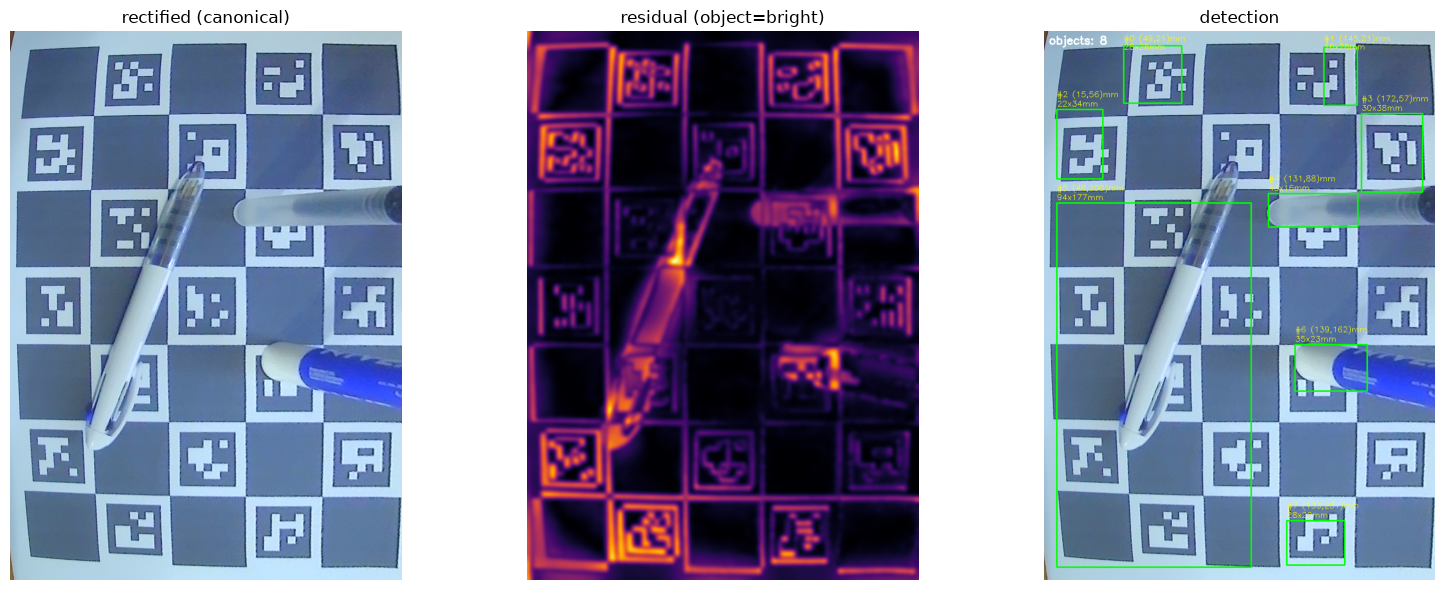

In [6]:
# 기준(빈 보드): 캘리브 사진 중 하나
empty = cv2.imread(sorted(glob.glob(os.path.join(CALIB_DIR, '*.jpg')))[0])
ref = bg.make_reference(empty, board, K, dist, SQ)
assert ref is not None, '기준 프레임에서 보드 미검출'

# 대상(물체): scene_images의 raw 프레임 (snap_raw_* 우선, 없으면 첫 이미지)
cands = sorted(glob.glob(os.path.join(OUTPUT_DIR, 'snap_raw_*.png'))) or \
        sorted(glob.glob(os.path.join(SCENE_DIR, '*.*')))
tgt = cv2.imread(cands[0]); print('대상:', os.path.basename(cands[0]))

det = bg.detect_objects_bgdiff(tgt, board, K, dist, ref, SQ,
                               thresh=THRESH, min_area_mm2=MIN_AREA_MM2)
assert det is not None, '대상에서 보드 미검출'
print('검출 물체:', len(det['objects']))
for i, o in enumerate(det['objects']):
    print(f"  #{i} center {tuple(round(v) for v in o['center_mm'])}mm  "
          f"size {tuple(round(v) for v in o['size_mm'])}mm  area {o['area_mm2']:.0f}mm2")

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(cv2.cvtColor(det['rect'], cv2.COLOR_BGR2RGB)); ax[0].set_title('rectified (canonical)')
ax[1].imshow(det['residual'], cmap='inferno'); ax[1].set_title('residual (object=bright)')
ax[2].imshow(cv2.cvtColor(bg.draw_canonical(det), cv2.COLOR_BGR2RGB)); ax[2].set_title('detection')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 실시간 실행 (웹캠)

**순서:** ① 보드만 두고 실행 → **`r`** 눌러 빈 보드를 기준으로 설정 → ② 물체들을 올리면 실시간 검출.
- **`r`**: 현재(빈 보드) 프레임을 기준으로 설정/갱신 (조명 바뀌면 다시 눌러 갱신)
- **`s`**: 스냅샷(raw+vis) 저장  ·  **`q`**: 종료

> 색 임계값이 없으니 조명/각도가 바뀌어도 대체로 안정적. 마커 잔차가 뜨면 `THRESH`를 올린다.

In [7]:
bg.run_live_bgdiff(K, dist, board, SQ, cam_index=CAM_INDEX, snapshot_dir=OUTPUT_DIR,
                   thresh=THRESH, min_area_mm2=MIN_AREA_MM2)
print('종료됨')

기준 설정
종료됨


## 관찰 & 다음

- **마커 잔차가 물체로 뜸**: `THRESH`↑ 또는 `min_area_mm2`↑. 기준을 현재 조명에서 다시(`r`) 잡으면 상쇄가 좋아진다.
- **세운 물체의 크기가 이상**: 정면투영 시차 때문. 검출·중심위치는 신뢰, 정확한 W×L×H는 02 방식(바닥 역투영+수직모서리)과 결합 예정.
- 다음 통합: 이 색-무관 마스크를 04 측정 파이프라인의 입력으로 써서 03/04의 색 의존을 제거 → 복수 물체 크기/중심/위치 + 실시간 가상 3D 반영.